In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd().resolve()

if (current_dir / "cartpole.py").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "cartpole.py").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not find cartpole.py in the current directory or its parent."
    )

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
REPORT_DIR = PROJECT_ROOT / "reports"
SRC_DIR = PROJECT_ROOT / "src"

for folder in [DATA_DIR, FIGURE_DIR, NOTEBOOK_DIR, REPORT_DIR, SRC_DIR]:
    folder.mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure dir:", FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning
Figure dir: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures


In [2]:
from cartpole import CartPole, remap_angle

STATE_NAMES = [
    "x",
    "x_dot",
    "theta",
    "theta_dot",
]

STATE_LABELS = [
    "cart position x",
    "cart velocity x_dot",
    "pole angle theta",
    "pole angular velocity theta_dot",
]

system = CartPole(visual=False)

print("Default state:", system.getState())
print("delta_time:", system.delta_time)
print("sim_steps:", system.sim_steps)

Default state: [0.         0.         3.14159265 0.        ]
delta_time: 0.1
sim_steps: 50


In [3]:
def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure to:", path)
    return path

In [4]:
def one_step_zero_force(initial_state):
    """
    Run exactly one performAction(0.0) call from the given initial state.

    initial_state shape: (4,)

    Returns:
        x0:         initial state, shape (4,)
        x_next:     next state after one action step, shape (4,)
        delta_x:    x_next - x0, shape (4,)
    """
    system = CartPole(visual=False)
    system.setState(np.asarray(initial_state, dtype=float))

    x0 = system.getState()
    system.performAction(0.0)
    x_next = system.getState()

    delta_x = x_next - x0

    return x0, x_next, delta_x

In [5]:
initial_state_demo = np.array([0.0, 1.0, np.pi, 2.0])

x0_demo, x_next_demo, delta_demo = one_step_zero_force(initial_state_demo)

print("x0_demo:", x0_demo)
print("x_next_demo:", x_next_demo)
print("delta_demo:", delta_demo)

print("\nShapes:")
print("x0_demo shape:", x0_demo.shape)
print("x_next_demo shape:", x_next_demo.shape)
print("delta_demo shape:", delta_demo.shape)

x0_demo: [0.         1.         3.14159265 2.        ]
x_next_demo: [0.09783787 0.93900877 3.32537394 1.53852637]
delta_demo: [ 0.09783787 -0.06099123  0.18378128 -0.46147363]

Shapes:
x0_demo shape: (4,)
x_next_demo shape: (4,)
delta_demo shape: (4,)


In [6]:
rng = np.random.default_rng(0)

base_state = np.array([
    rng.uniform(-2.0, 2.0),          # x
    rng.uniform(-3.0, 3.0),          # x_dot
    rng.uniform(-np.pi, np.pi),      # theta
    rng.uniform(-5.0, 5.0),          # theta_dot
])

print("Base state:")
for name, value in zip(STATE_NAMES, base_state):
    print(f"{name}: {value}")

Base state:
x: 0.5478467492858172
x_dot: -1.3812797174167781
theta: -2.8841484100105235
theta_dot: -4.834723644714709


In [7]:
scan_ranges = {
    0: np.linspace(-5.0, 5.0, 121),          # x
    1: np.linspace(-10.0, 10.0, 121),        # x_dot
    2: np.linspace(-np.pi, np.pi, 121),      # theta
    3: np.linspace(-15.0, 15.0, 121),        # theta_dot
}
base_state = np.array([0.0, 1.0, 0.8, 2.0])
# scan_ranges.items()

In [8]:
def scan_single_variable(base_state, variable_index, scan_values):
    """
    Scan one state variable while keeping the other three fixed.

    Returns:
        X0_values:      initial states, shape (N_scan, 4)
        X_next_values:  next states, shape (N_scan, 4)
        Delta_values:   state changes, shape (N_scan, 4)
    """
    X0_values = []
    X_next_values = []
    Delta_values = []

    for value in scan_values:
        state = base_state.copy()
        state[variable_index] = value

        x0, x_next, delta_x = one_step_zero_force(state)

        X0_values.append(x0)
        X_next_values.append(x_next)
        Delta_values.append(delta_x)

    X0_values = np.array(X0_values)
    X_next_values = np.array(X_next_values)
    Delta_values = np.array(Delta_values)

    return X0_values, X_next_values, Delta_values

In [9]:
scan_results = {}

for variable_index, scan_values in scan_ranges.items():
    X0_values, X_next_values, Delta_values = scan_single_variable(
        base_state=base_state,
        variable_index=variable_index,
        scan_values=scan_values,
    )

    scan_results[variable_index] = {
        "scan_values": scan_values,
        "X0": X0_values,
        "X_next": X_next_values,
        "Delta": Delta_values,
    }

    print("Scanned variable:", STATE_NAMES[variable_index])
    print("  scan_values shape:", scan_values.shape)
    print("  X0 shape:", X0_values.shape)
    print("  X_next shape:", X_next_values.shape)
    print("  Delta shape:", Delta_values.shape)
    print()

Scanned variable: x
  scan_values shape: (121,)
  X0 shape: (121, 4)
  X_next shape: (121, 4)
  Delta shape: (121, 4)

Scanned variable: x_dot
  scan_values shape: (121,)
  X0 shape: (121, 4)
  X_next shape: (121, 4)
  Delta shape: (121, 4)

Scanned variable: theta
  scan_values shape: (121,)
  X0 shape: (121, 4)
  X_next shape: (121, 4)
  Delta shape: (121, 4)

Scanned variable: theta_dot
  scan_values shape: (121,)
  X0 shape: (121, 4)
  X_next shape: (121, 4)
  Delta shape: (121, 4)



## `plot_scan_matrix`
| | 列 0: 输出 x | 列 1: 输出 x_dot | 列 2: 输出 theta | 列 3: 输出 theta_dot |
|---|---|---|---|---|
| **行 0: 扫描输入 x** | x 变化对 x 的影响 | x 变化对 x_dot 的影响 | x 变化对 theta 的影响 | x 变化对 theta_dot 的影响 |
| **行 1: 扫描输入 x_dot** | x_dot 变化对 x 的影响 | x_dot 变化对 x_dot 的影响 | x_dot 变化对 theta 的影响 | x_dot 变化对 theta_dot 的影响 |
| **行 2: 扫描输入 theta** | theta 变化对 x 的影响 | theta 变化对 x_dot 的影响 | theta 变化对 theta 的影响 | theta 变化对 theta_dot 的影响 |
| **行 3: 扫描输入 theta_dot** | theta_dot 变化对 x 的影响 | theta_dot 变化对 x_dot 的影响 | theta_dot 变化对 theta 的影响 | theta_dot 变化对 theta_dot 的影响 |

In [11]:
def plot_scan_matrix(target_key, filename, title):
    """
    Plot 4 by 4 scan matrix.

    Rows: scanned input variable.
    Columns: output state component.
    target_key: "X_next" or "Delta".
    """
    fig, axes = plt.subplots(4, 4, figsize=(16, 12))

    for row, variable_index in enumerate(range(4)):
        scan_values = scan_results[variable_index]["scan_values"]
        target_values = scan_results[variable_index][target_key]

        for col, output_index in enumerate(range(4)):
            ax = axes[row, col]

            ax.plot(scan_values, target_values[:, output_index])
            ax.grid(True)

            if row == 0:
                ax.set_title(f"output: {STATE_NAMES[output_index]}")

            if col == 0:
                ax.set_ylabel(f"scan {STATE_NAMES[variable_index]}")

            if row == 3:
                ax.set_xlabel(STATE_NAMES[variable_index])

    fig.suptitle(title)
    fig.tight_layout()

    save_figure(fig, filename)
    plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_2_scan_next_state_matrix.png


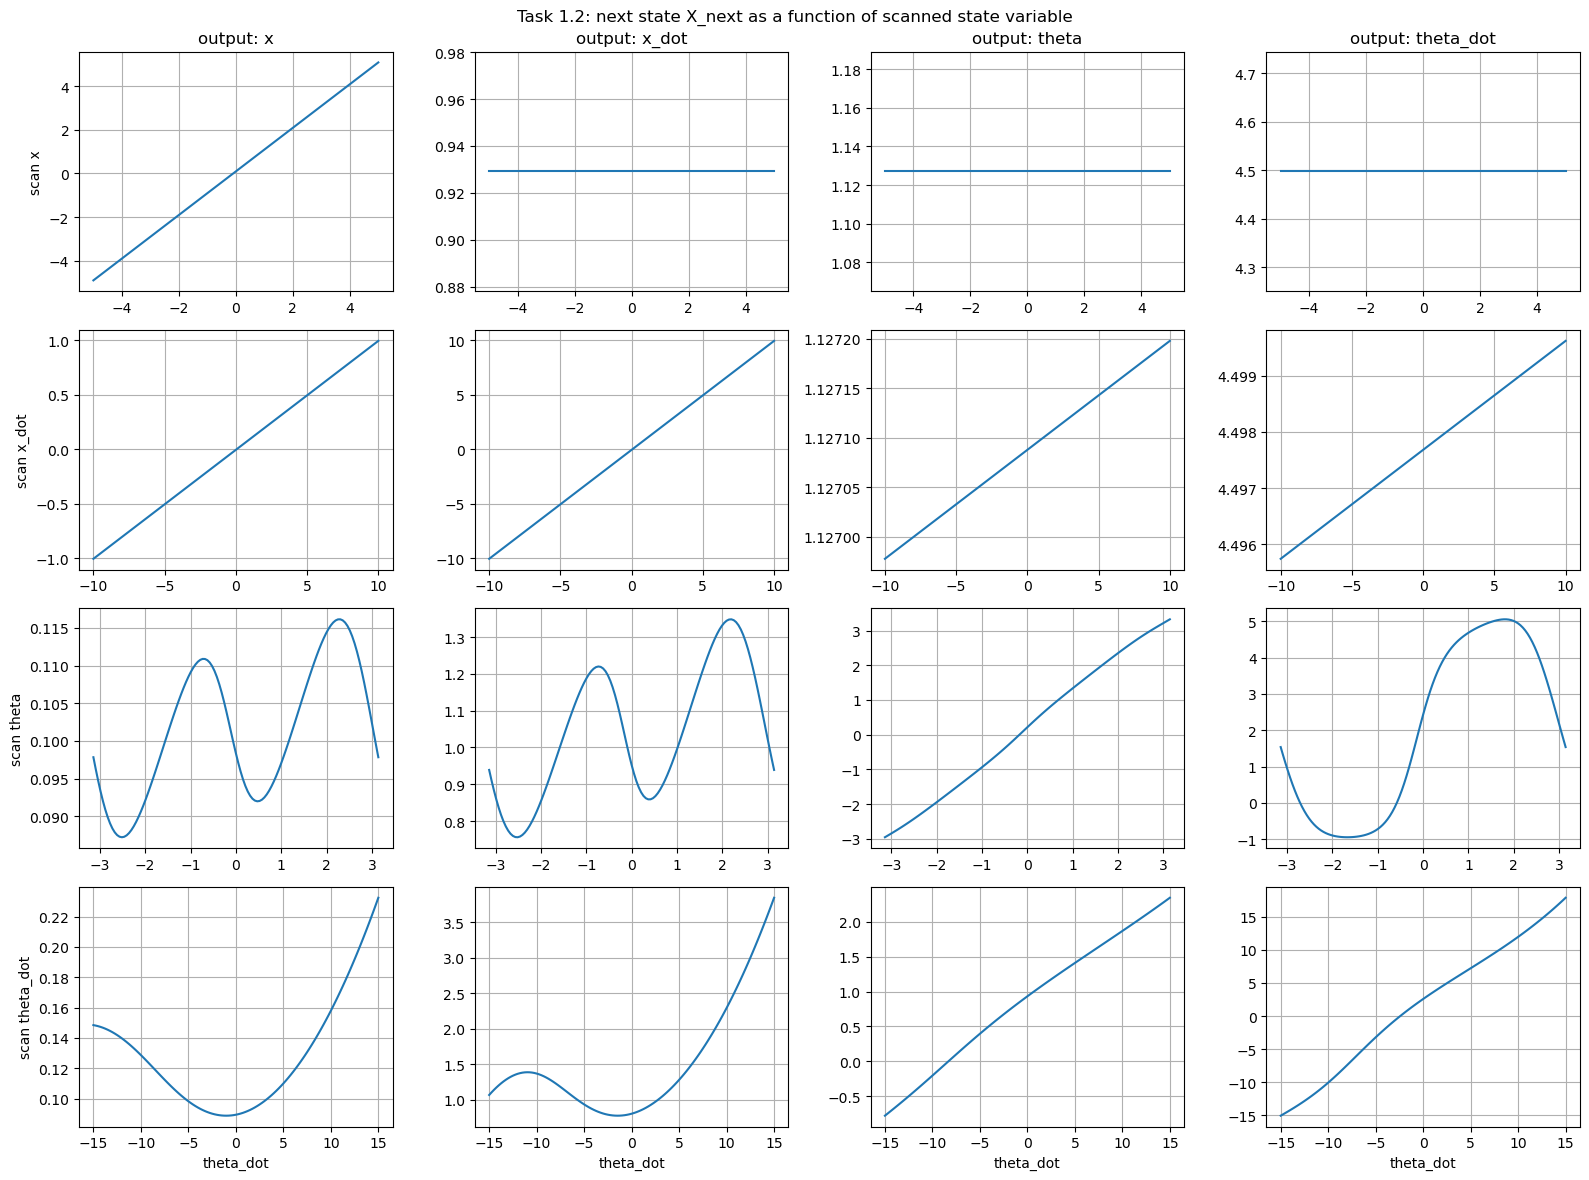

In [12]:
plot_scan_matrix(
    target_key="X_next",
    filename="sf3_task1_2_scan_next_state_matrix.png",
    title="Task 1.2: next state X_next as a function of scanned state variable",
)

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_2_scan_delta_state_matrix.png


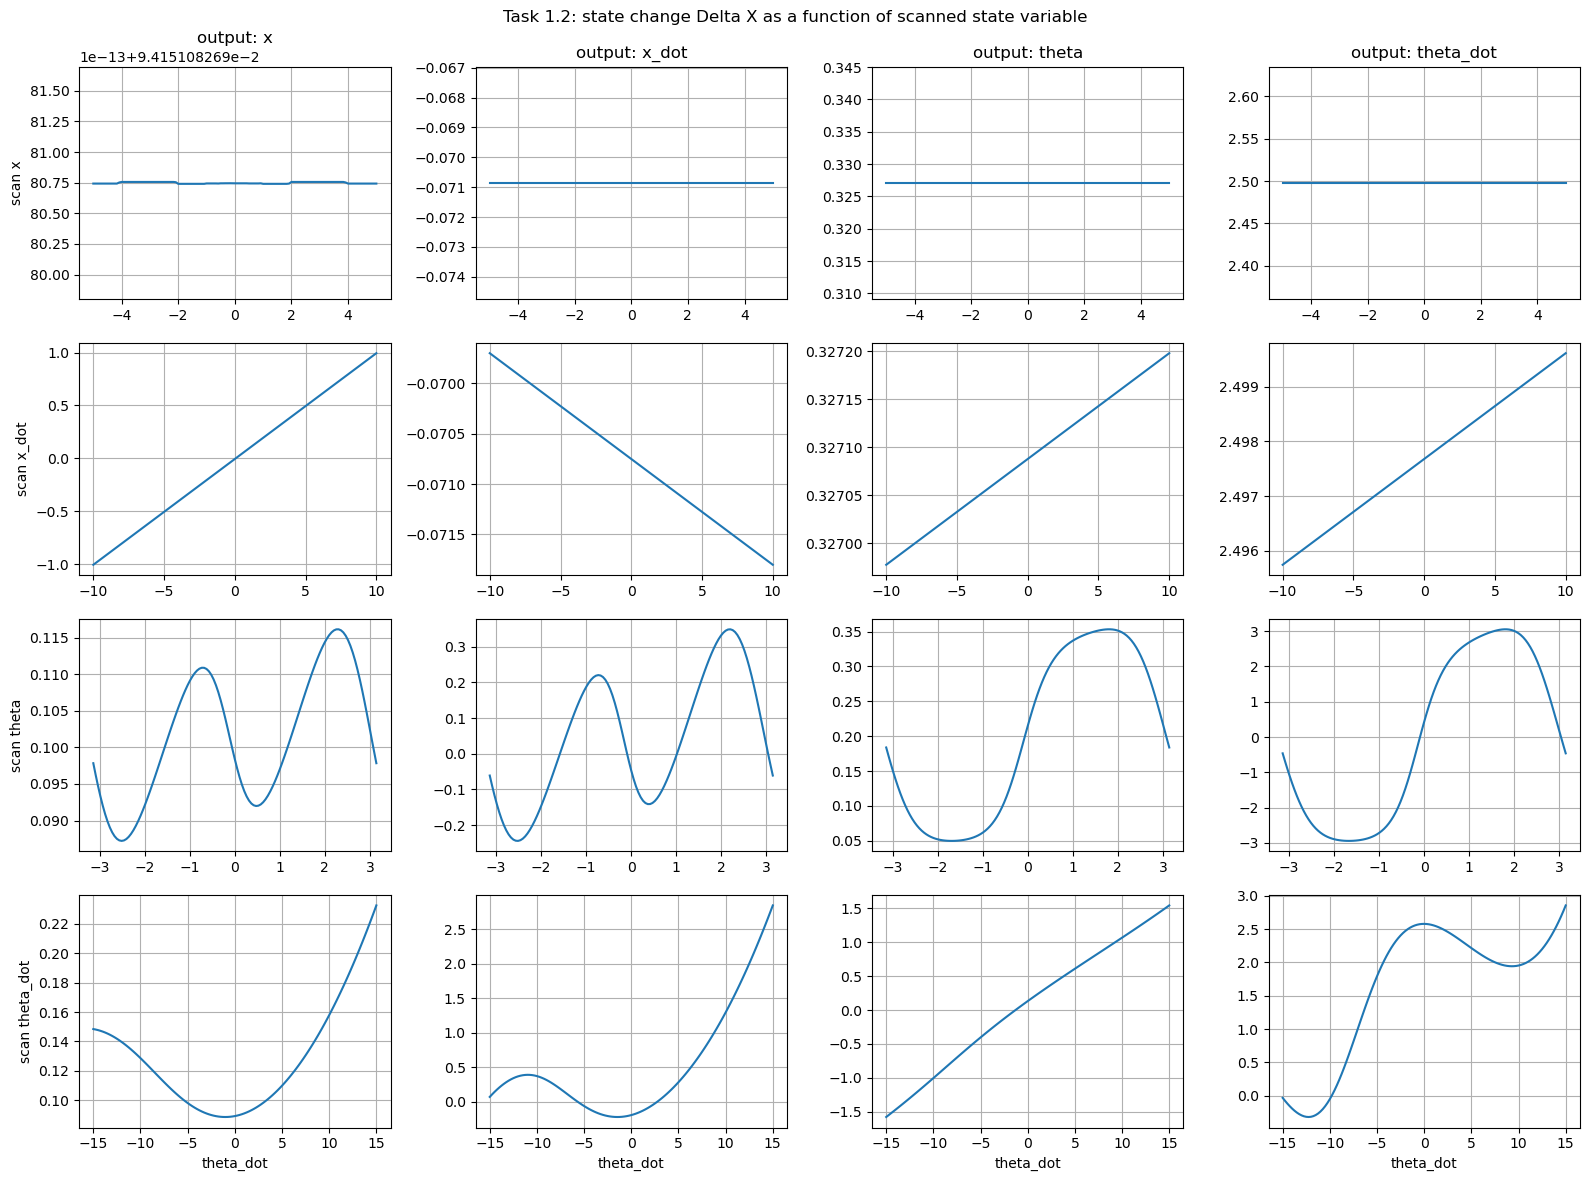

In [13]:
plot_scan_matrix(
    target_key="Delta",
    filename="sf3_task1_2_scan_delta_state_matrix.png",
    title="Task 1.2: state change Delta X as a function of scanned state variable",
)

In [14]:
print("Range of Delta components under each scan:")
print()

for variable_index in range(4):
    Delta_values = scan_results[variable_index]["Delta"]

    delta_ranges = np.ptp(Delta_values, axis=0)

    print("Scanned variable:", STATE_NAMES[variable_index])
    for output_index in range(4):
        print(f"  range of Delta {STATE_NAMES[output_index]}: {delta_ranges[output_index]:.6e}")
    print()

Range of Delta components under each scan:

Scanned variable: x
  range of Delta x: 1.554312e-15
  range of Delta x_dot: 0.000000e+00
  range of Delta theta: 0.000000e+00
  range of Delta theta_dot: 0.000000e+00

Scanned variable: x_dot
  range of Delta x: 1.999886e+00
  range of Delta x_dot: 2.103768e-03
  range of Delta theta: 2.200954e-04
  range of Delta theta_dot: 3.872929e-03

Scanned variable: theta
  range of Delta x: 2.891018e-02
  range of Delta x_dot: 5.922474e-01
  range of Delta theta: 3.035435e-01
  range of Delta theta_dot: 5.997118e+00

Scanned variable: theta_dot
  range of Delta x: 1.437409e-01
  range of Delta x_dot: 3.063132e+00
  range of Delta theta: 3.117843e+00
  range of Delta theta_dot: 3.174095e+00



Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_2_delta_vs_theta.png


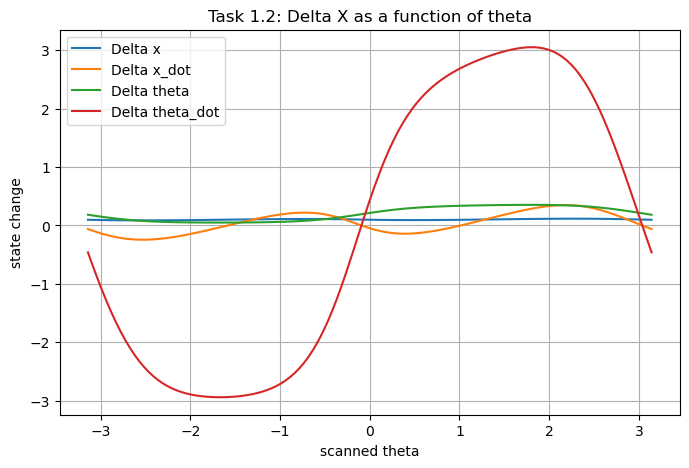

In [15]:
theta_scan_values = scan_results[2]["scan_values"]
Delta_theta_scan = scan_results[2]["Delta"]

fig, ax = plt.subplots(figsize=(8, 5))

for output_index in range(4):
    ax.plot(
        theta_scan_values,
        Delta_theta_scan[:, output_index],
        label=f"Delta {STATE_NAMES[output_index]}",
    )

ax.set_xlabel("scanned theta")
ax.set_ylabel("state change")
ax.set_title("Task 1.2: Delta X as a function of theta")
ax.legend()
ax.grid(True)

save_figure(fig, "sf3_task1_2_delta_vs_theta.png")
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_2_delta_vs_x.png


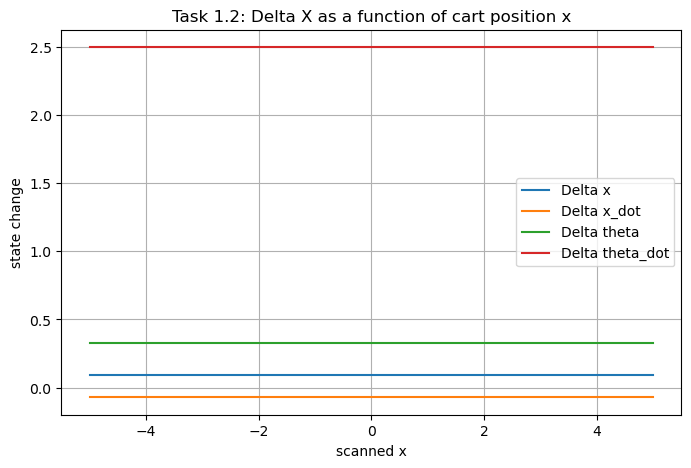

In [16]:
x_scan_values = scan_results[0]["scan_values"]
Delta_x_scan = scan_results[0]["Delta"]

fig, ax = plt.subplots(figsize=(8, 5))

for output_index in range(4):
    ax.plot(
        x_scan_values,
        Delta_x_scan[:, output_index],
        label=f"Delta {STATE_NAMES[output_index]}",
    )

ax.set_xlabel("scanned x")
ax.set_ylabel("state change")
ax.set_title("Task 1.2: Delta X as a function of cart position x")
ax.legend()
ax.grid(True)

save_figure(fig, "sf3_task1_2_delta_vs_x.png")
plt.show()

In [17]:
def evaluate_two_variable_grid(
    base_state,
    variable_index_a,
    values_a,
    variable_index_b,
    values_b,
):
    """
    Evaluate Delta X on a 2D grid over two state variables.

    Other state variables are fixed to base_state.
    """
    A_grid, B_grid = np.meshgrid(values_a, values_b)

    A_flat = A_grid.ravel()
    B_flat = B_grid.ravel()

    X0_values = []
    X_next_values = []
    Delta_values = []

    for value_a, value_b in zip(A_flat, B_flat):
        state = base_state.copy()
        state[variable_index_a] = value_a
        state[variable_index_b] = value_b

        x0, x_next, delta_x = one_step_zero_force(state)

        X0_values.append(x0)
        X_next_values.append(x_next)
        Delta_values.append(delta_x)

    X0_values = np.array(X0_values)
    X_next_values = np.array(X_next_values)
    Delta_values = np.array(Delta_values)

    return A_flat, B_flat, X0_values, X_next_values, Delta_values

In [18]:
def plot_delta_contour(
    variable_index_a,
    values_a,
    variable_index_b,
    values_b,
    output_index,
    filename,
):
    """
    Make a tricontourf plot of one component of Delta X
    over a 2D slice of state space.
    """
    A_flat, B_flat, X0_values, X_next_values, Delta_values = evaluate_two_variable_grid(
        base_state=base_state,
        variable_index_a=variable_index_a,
        values_a=values_a,
        variable_index_b=variable_index_b,
        values_b=values_b,
    )

    target = Delta_values[:, output_index]

    fig, ax = plt.subplots(figsize=(7, 5))

    contour = ax.tricontourf(A_flat, B_flat, target, levels=30)
    fig.colorbar(contour, ax=ax, label=f"Delta {STATE_NAMES[output_index]}")

    ax.set_xlabel(STATE_NAMES[variable_index_a])
    ax.set_ylabel(STATE_NAMES[variable_index_b])
    ax.set_title(
        f"Task 1.2: Delta {STATE_NAMES[output_index]} "
        f"over {STATE_NAMES[variable_index_a]}-{STATE_NAMES[variable_index_b]} slice"
    )

    save_figure(fig, filename)
    plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_2_contour_theta_thetadot_delta_thetadot.png


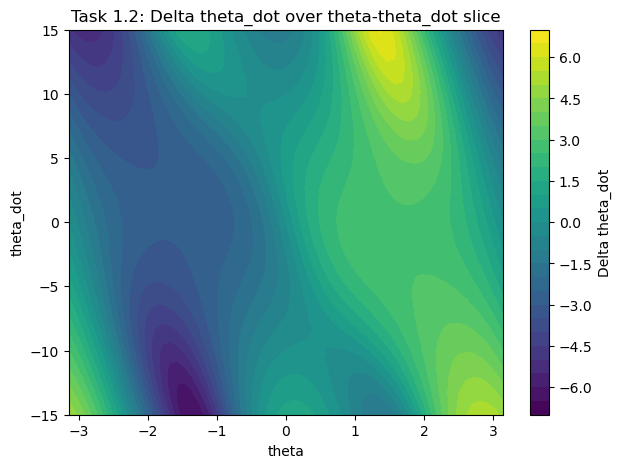

In [19]:
theta_values = np.linspace(-np.pi, np.pi, 61)
theta_dot_values = np.linspace(-15.0, 15.0, 61)

plot_delta_contour(
    variable_index_a=2,
    values_a=theta_values,
    variable_index_b=3,
    values_b=theta_dot_values,
    output_index=3,
    filename="sf3_task1_2_contour_theta_thetadot_delta_thetadot.png",
)

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_2_contour_x_theta_delta_thetadot.png


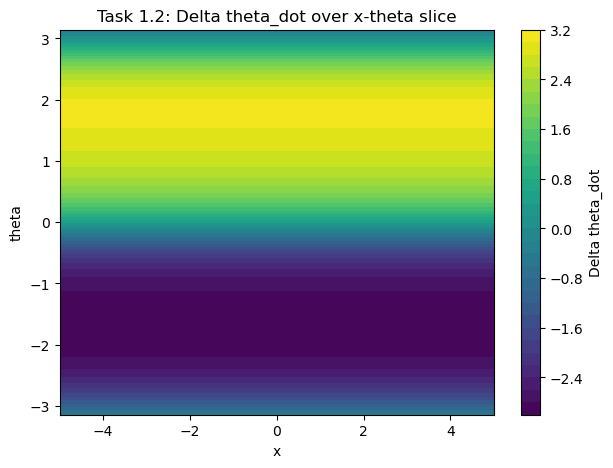

In [20]:
x_values = np.linspace(-5.0, 5.0, 61)
theta_values = np.linspace(-np.pi, np.pi, 61)

plot_delta_contour(
    variable_index_a=0,
    values_a=x_values,
    variable_index_b=2,
    values_b=theta_values,
    output_index=3,
    filename="sf3_task1_2_contour_x_theta_delta_thetadot.png",
)

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_2_contour_xdot_theta_delta_xdot.png


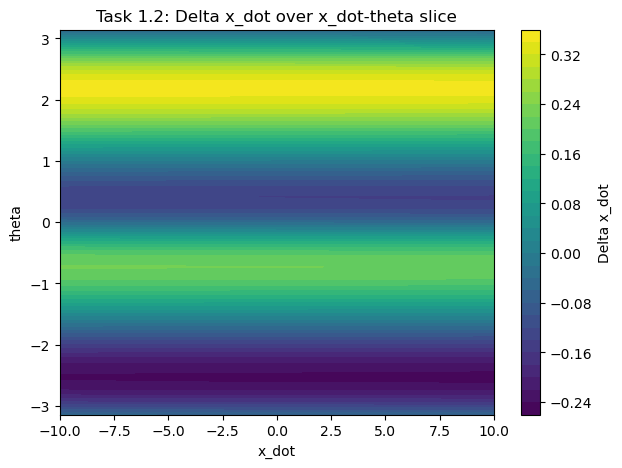

In [21]:
x_dot_values = np.linspace(-10.0, 10.0, 61)
theta_values = np.linspace(-np.pi, np.pi, 61)

plot_delta_contour(
    variable_index_a=1,
    values_a=x_dot_values,
    variable_index_b=2,
    values_b=theta_values,
    output_index=1,
    filename="sf3_task1_2_contour_xdot_theta_delta_xdot.png",
)

In [22]:
task1_2_data_path = DATA_DIR / "task1_2_scan_results.npz"

np.savez(
    task1_2_data_path,
    base_state=base_state,
    x_scan_values=scan_results[0]["scan_values"],
    x_next_scan_x=scan_results[0]["X_next"],
    delta_scan_x=scan_results[0]["Delta"],
    theta_scan_values=scan_results[2]["scan_values"],
    x_next_scan_theta=scan_results[2]["X_next"],
    delta_scan_theta=scan_results[2]["Delta"],
)

print("Saved scan data to:", task1_2_data_path)

Saved scan data to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/data/task1_2_scan_results.npz


In Task 1.2, I examined the one-step map from the current state $X$ to the next state $X_{\text{next}}$, and then the more useful modelling target $\Delta X = X_{\text{next}}-X$. The map $X \mapsto X_{\text{next}}$ is nearly linear over one action step because the step is short. However, modelling \(\Delta X\) is more informative because it removes the identity part of the mapping and exposes the true local dynamics.

The scan over cart position $x$ showed essentially no effect on $\Delta X$, indicating that the free dynamics are translationally invariant in cart position. By contrast, scans over $\theta$, $\dot{\theta}$, and $\dot{x}$ showed clear effects on the change in velocity variables. This motivates modelling $\Delta X$ rather than $X_{\text{next}}$ directly.